In [32]:
import pandas as pd

In [33]:
import numpy as np

In [34]:
import seaborn as sns
!pip install --upgrade seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import matplotlib.pyplot as plt
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
np.random.seed(42)
num_samples=500
year_of_experience=np.random.randint(2,21,size=num_samples)
slope=(200_000-60_000)/18
intercept=60_000
salaries=slope*year_of_experience+intercept+np.random.normal(0,10_000)
data={'year_of_experience':year_of_experience,'salary':salaries}
df=pd.DataFrame(data)

In [37]:
df.describe()

,year_of_experience,salary
count,500.000000,500.000000
mean,10.616000,135384.446676
std,5.662922,44044.945994
min,2.000000,68371.113343
25%,5.750000,97537.780010
50%,10.000000,130593.335565
75%,16.000000,177260.002232
max,20.000000,208371.113343


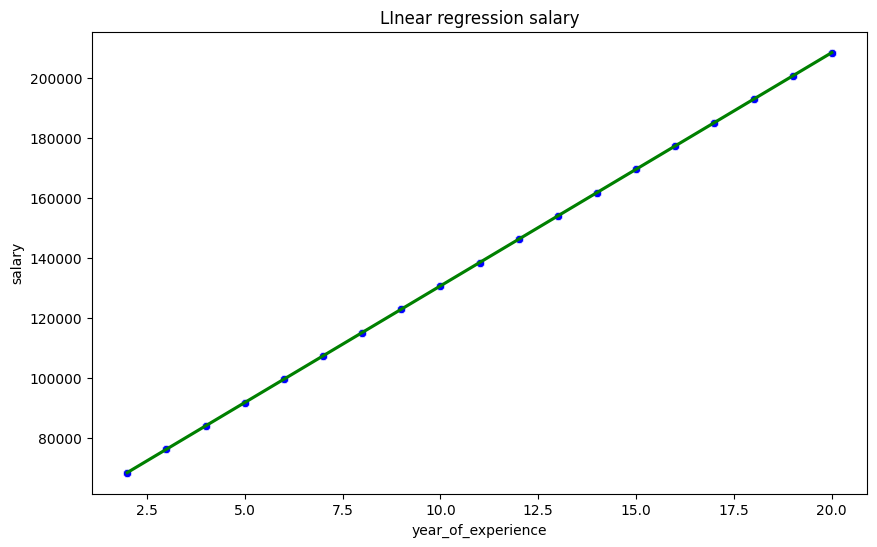

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='year_of_experience',y='salary',data=df,color='blue')
sns.regplot(x='year_of_experience',y='salary',data=df,scatter=False,color='green')
plt.xlabel('year_of_experience')
plt.ylabel('salary')
plt.title('LInear regression salary')
plt.show()

In [48]:
x=df[['year_of_experience']]
y=df['salary']

In [50]:
from sklearn.model_selection import train_test_split

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7777.78]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year_of_experience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.282e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [55]:
lr.score(x_train,y_train)

1.0

In [56]:
lr.score(x_test,y_test)

1.0

In [57]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [58]:
y_pred=lr.predict(x_test)

In [60]:
mean_absolute_error(y_test,y_pred)

3.9726728573441505e-11

In [61]:
mean_squared_error(y_test,y_pred)

2.4585131294056066e-21

In [62]:
r2_score(y_test,y_pred)

1.0

In [63]:
lr.coef_

array([7777.77777778])

In [64]:
lr.intercept_

np.float64(52815.55778747557)

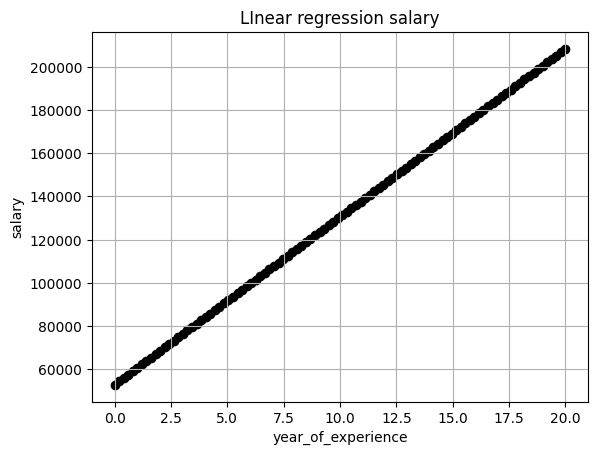

In [75]:
coefficient=lr.coef_
intercept=lr.intercept_
x=np.linspace(0,20,100)
y=coefficient*x+intercept
plt.scatter(x,y,label=f'y={coefficient[0]*x}+{intercept}',color='black')
plt.xlabel('year_of_experience')
plt.ylabel('salary')
plt.title('LInear regression salary')

plt.grid()
plt.show()


In [70]:
#by plotly
import plotly.express as px

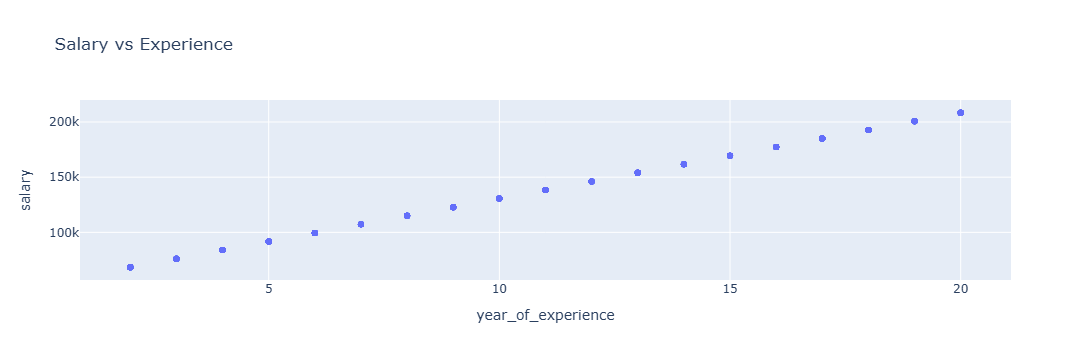

In [72]:
fig = px.scatter(
    df,
    x='year_of_experience',
    y='salary',
    title='Salary vs Experience'
)

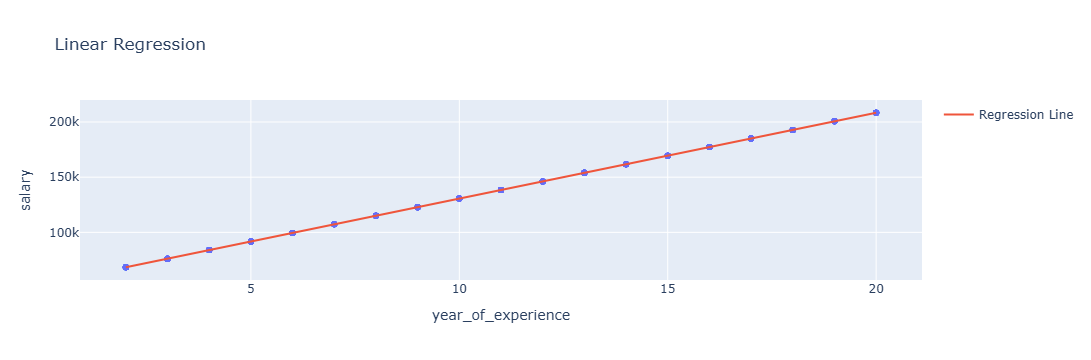

In [78]:
fig = px.scatter(
    df,
    x='year_of_experience',
    y='salary',
    title='Linear Regression'
)

fig.add_scatter(
    x=df['year_of_experience'],
    y=df['salary'],
    mode='lines',
    name='Regression Line'
)

fig.show()